## LUT to NetworkX Graph Conversion

This project provides a Python script to convert Look-Up Tables (LUTs) into NetworkX graphs. The script reads LUT data from a .dot file and than coverts it into a graph structure that can be analyzed and visualized using NetworkX.

The objective of this project is to extract meaningful insights from LUTs by representing them as graphs, allowing for easier analysis and visualization of the relationships between different components in the LUT.

 * Author: Olavo Alves Barros Silva
 * Contact: olavo.barros@ufv.com
 * Date: 2026-04-30
 * License: [License Type]
 * Description: [Brief Description]



## Installation and Usage

## Libraries and Dependencies

In [7]:
# Graph related imports
import networkx as nx
from pyvis import  network as net


# Data manipulation
import numpy as np
import pandas as pd

# General utilities
import os
import sys
import json
import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

In [8]:
# Parameterized font sizes for easy adjustments
FONT_SIZE_BASE = 8
LABEL_SIZE = 8
TITLE_SIZE = 8
LEGEND_SIZE = 7
TICK_SIZE = 7

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "text.usetex": False,
    "svg.fonttype": "none",
    
    "font.size": FONT_SIZE_BASE,
    "axes.labelsize": LABEL_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,

    "lines.linewidth": 1,
    "axes.grid": True,
    "grid.linewidth": 0.3,
    
    "figure.dpi": 300,
    "savefig.dpi": 300,
})



In [14]:
DATA_PATH = Path("../data")

GRAPH_NAME = "paviaU_"
JSON_FILE = DATA_PATH / f"{GRAPH_NAME}.json"

RESULTS_PATH = Path("../../results") / GRAPH_NAME
RESULTS_PATH.mkdir(parents=True, exist_ok=True)


## Visualization Functions

In [10]:
def graph_visualization(graph):
  """Graph visualization using Pyvis

  Args:
      graph (networkx.direct): A direct oriented graph to be visualized
  """

  # Create the folder RESULTS_PATH/GRAPH_NAME/vis if it does not exist
  vis_path = RESULTS_PATH / GRAPH_NAME / "vis"
  vis_path.mkdir(parents=True, exist_ok=True)

  nt = net.Network(notebook = True, directed=True)
  nt.from_nx(graph)
  nt.save_graph('digraph_visualization.html')
  

## Graph Construction Functions

In [11]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

def get_boolean_bias(lut_string):
    """
    Calculates the Boolean Bias (Node Attribute) - the ratio of 1s in the truth table.
    A bias near 0 or 1 indicates highly predictable/redundant logic.
    """
    if not lut_string or not isinstance(lut_string, str):
        return 0.5
    return lut_string.count('1') / len(lut_string)

def get_boolean_sensitivity(lut_string, input_index, num_inputs):
    """
    Calculates the Boolean Sensitivity (Edge Strength).
    It measures the probability that flipping input_index will flip the LUT output.
    """
    if not lut_string or not isinstance(lut_string, str) or len(lut_string) != (1 << num_inputs):
        return 1.0 # Default structural weight if truth table is missing
    
    flips = 0
    # Iterate over all 2^k states where the specific input is 0
    for state in range(1 << num_inputs):
        if (state & (1 << input_index)) == 0:
            toggled_state = state | (1 << input_index)
            # Compare outputs. (Direction of string doesn't matter for symmetric pairing)
            if lut_string[state] != lut_string[toggled_state]: 
                flips += 1
                
    # Divide by the number of pairs (2^(k-1))
    return flips / (1 << (num_inputs - 1))

def build_graph_from_yosys(json_path):
    import json
    with open(json_path, 'r') as f:
        design = json.load(f)

    module_name = list(design['modules'].keys())[0]
    cells = design['modules'][module_name].get('cells', {})
    ports = design['modules'][module_name].get('ports', {})

    G = nx.DiGraph()

    # 1. Register Ports
    for port_name, port_data in ports.items():
        direction = port_data.get('direction')
        if direction == 'input':
            for bit in port_data.get('bits', []):
                G.add_node(bit, type='input', tag=port_name, color='blue')
        elif direction == 'output':
            for bit in port_data.get('bits', []):
                G.add_node(f'{port_name}_{bit}', type='output', tag=port_name, color='red')

    # 2. Register LUT Nodes with Boolean Bias
    for cell_name, cell_data in cells.items():
        if cell_data.get('type') == '$lut':
            node_name = cell_data.get('connections', {}).get('Y', [cell_name])[0]
            lut_str = cell_data.get('parameters', {}).get('LUT', '')
            
            # Add Node Attribute: Boolean Bias
            bias = get_boolean_bias(lut_str)
            
            G.add_node(node_name,
                       type='$lut',
                       tag=cell_name,
                       bias=bias,
                       color='green')

    output_bit_to_node = {}
    for port_name, port_data in ports.items():
        if port_data.get('direction') == 'output':
            for bit in port_data.get('bits', []):
                output_bit_to_node[bit] = f'{port_name}_{bit}'

    # 3. Create Edges with Boolean Sensitivity Weights
    for cell_name, cell_data in cells.items():
        if cell_data.get('type') == '$lut':
            connections = cell_data.get('connections', {})
            node = connections.get('Y', [cell_name])[0]
            lut_str = cell_data.get('parameters', {}).get('LUT', '')

            for port, bits in connections.items():
                if port == 'A':
                    num_inputs = len(bits)
                    for input_idx, bit in enumerate(bits):
                        if G.has_node(bit):
                            # Add Edge Attribute: Boolean Sensitivity
                            edge_strength = get_boolean_sensitivity(lut_str, input_idx, num_inputs)
                            G.add_edge(bit, node, weight=edge_strength)
                            
                elif port == 'Y':
                    for bit in bits:
                        if bit in output_bit_to_node:
                            # Final output edges carry full weight
                            G.add_edge(node, output_bit_to_node[bit], weight=1.0)

    return G

--- INF 791: Complex Network Metrics ---
(b) Average Degree (in + out): 3.47
(c) Number of Weakly Connected Components: 732
(d) Global Clustering Coefficient: 0.0037
(f) Average Neighborhood Overlap: 0.0028
(g) Average Path Length (LCC): 6.39


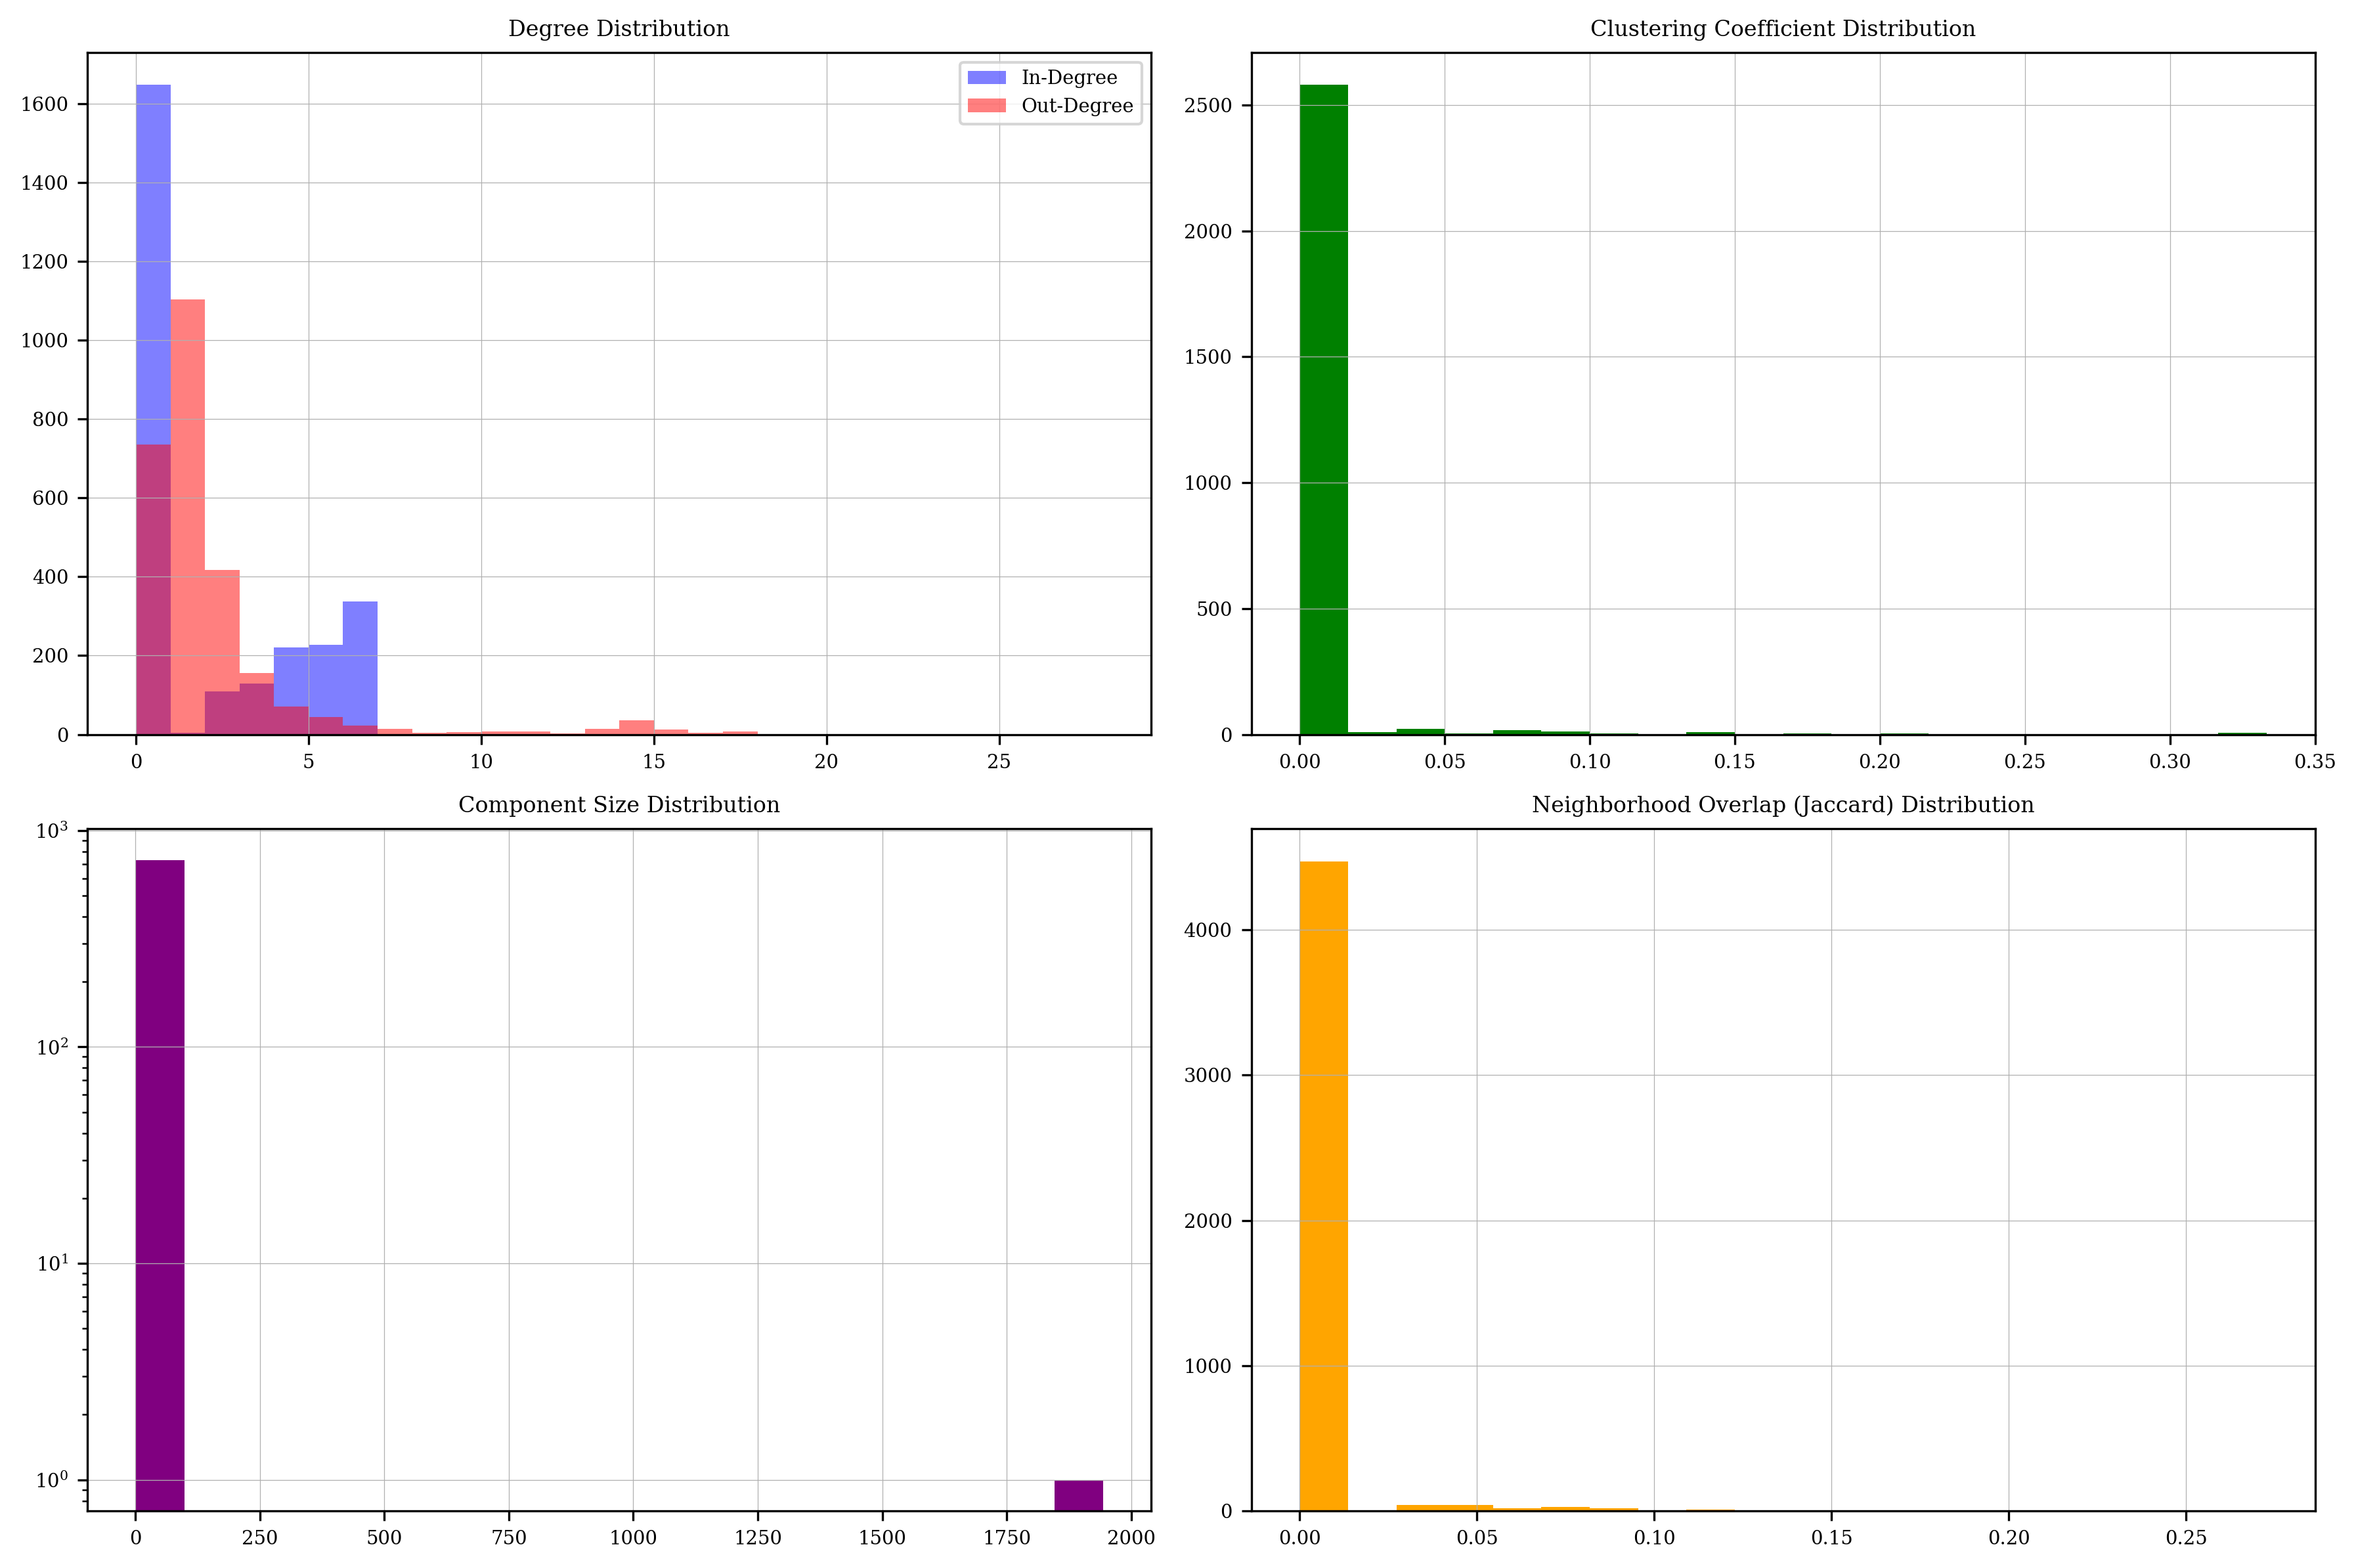

In [12]:
def calculate_tp1_metrics(G):
    print("--- INF 791: Complex Network Metrics ---")
    
    # b) Degree Distribution & Average Degree
    in_degrees = [d for n, d in G.in_degree()]
    out_degrees = [d for n, d in G.out_degree()]
    avg_degree = np.mean([d for n, d in G.degree()])
    print(f"(b) Average Degree (in + out): {avg_degree:.2f}")
    
    # c) Number of Components
    # Using weakly connected because hardware DAGs are rarely strongly connected
    components = list(nx.weakly_connected_components(G))
    print(f"(c) Number of Weakly Connected Components: {len(components)}")
    
    # d) Clustering Coefficient
    # Convert to undirected for standard clustering metrics
    G_undir = G.to_undirected()
    clustering_coeffs = nx.clustering(G_undir)
    global_clustering = nx.average_clustering(G_undir)
    print(f"(d) Global Clustering Coefficient: {global_clustering:.4f}")
    
    # e) Component Size Distribution
    component_sizes = [len(c) for c in components]
    
    # f) Neighborhood Overlap (Jaccard Coefficient for edges)
    overlap_preds = nx.jaccard_coefficient(G_undir, G_undir.edges())
    overlaps = [p for u, v, p in overlap_preds]
    avg_overlap = np.mean(overlaps) if overlaps else 0
    print(f"(f) Average Neighborhood Overlap: {avg_overlap:.4f}")
    
    # g) Average Path Length
    # Calculated on the Largest Connected Component (LCC) to avoid infinity errors
    lcc = max(nx.weakly_connected_components(G), key=len)
    G_lcc = G_undir.subgraph(lcc)
    avg_path = nx.average_shortest_path_length(G_lcc)
    print(f"(g) Average Path Length (LCC): {avg_path:.2f}")
    
    # --- PLOTTING ---
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    
    # Plot 1: Degree Distribution
    axs[0, 0].hist(in_degrees, bins=range(max(in_degrees)+2), alpha=0.5, label='In-Degree', color='blue')
    axs[0, 0].hist(out_degrees, bins=range(max(out_degrees)+2), alpha=0.5, label='Out-Degree', color='red')
    axs[0, 0].set_title('Degree Distribution')
    axs[0, 0].legend()
    
    # Plot 2: Clustering Coefficient
    axs[0, 1].hist(list(clustering_coeffs.values()), bins=20, color='green')
    axs[0, 1].set_title('Clustering Coefficient Distribution')
    
    # Plot 3: Component Sizes
    axs[1, 0].hist(component_sizes, bins=20, color='purple')
    axs[1, 0].set_title('Component Size Distribution')
    axs[1, 0].set_yscale('log') # Log scale is useful for component sizes
    
    # Plot 4: Neighborhood Overlap
    axs[1, 1].hist(overlaps, bins=20, color='orange')
    axs[1, 1].set_title('Neighborhood Overlap (Jaccard) Distribution')
    
    plt.tight_layout()
    plt.show()

# Run the metrics
calculate_tp1_metrics(G)

Graph constructed with 2674 nodes and 4646 edges.
--- INF 791: Complex Network Metrics ---
(b) Average Degree (in + out): 3.47
(c) Number of Weakly Connected Components: 732
(d) Global Clustering Coefficient: 0.0037
(f) Average Neighborhood Overlap: 0.0028
(g) Average Path Length (LCC): 6.39


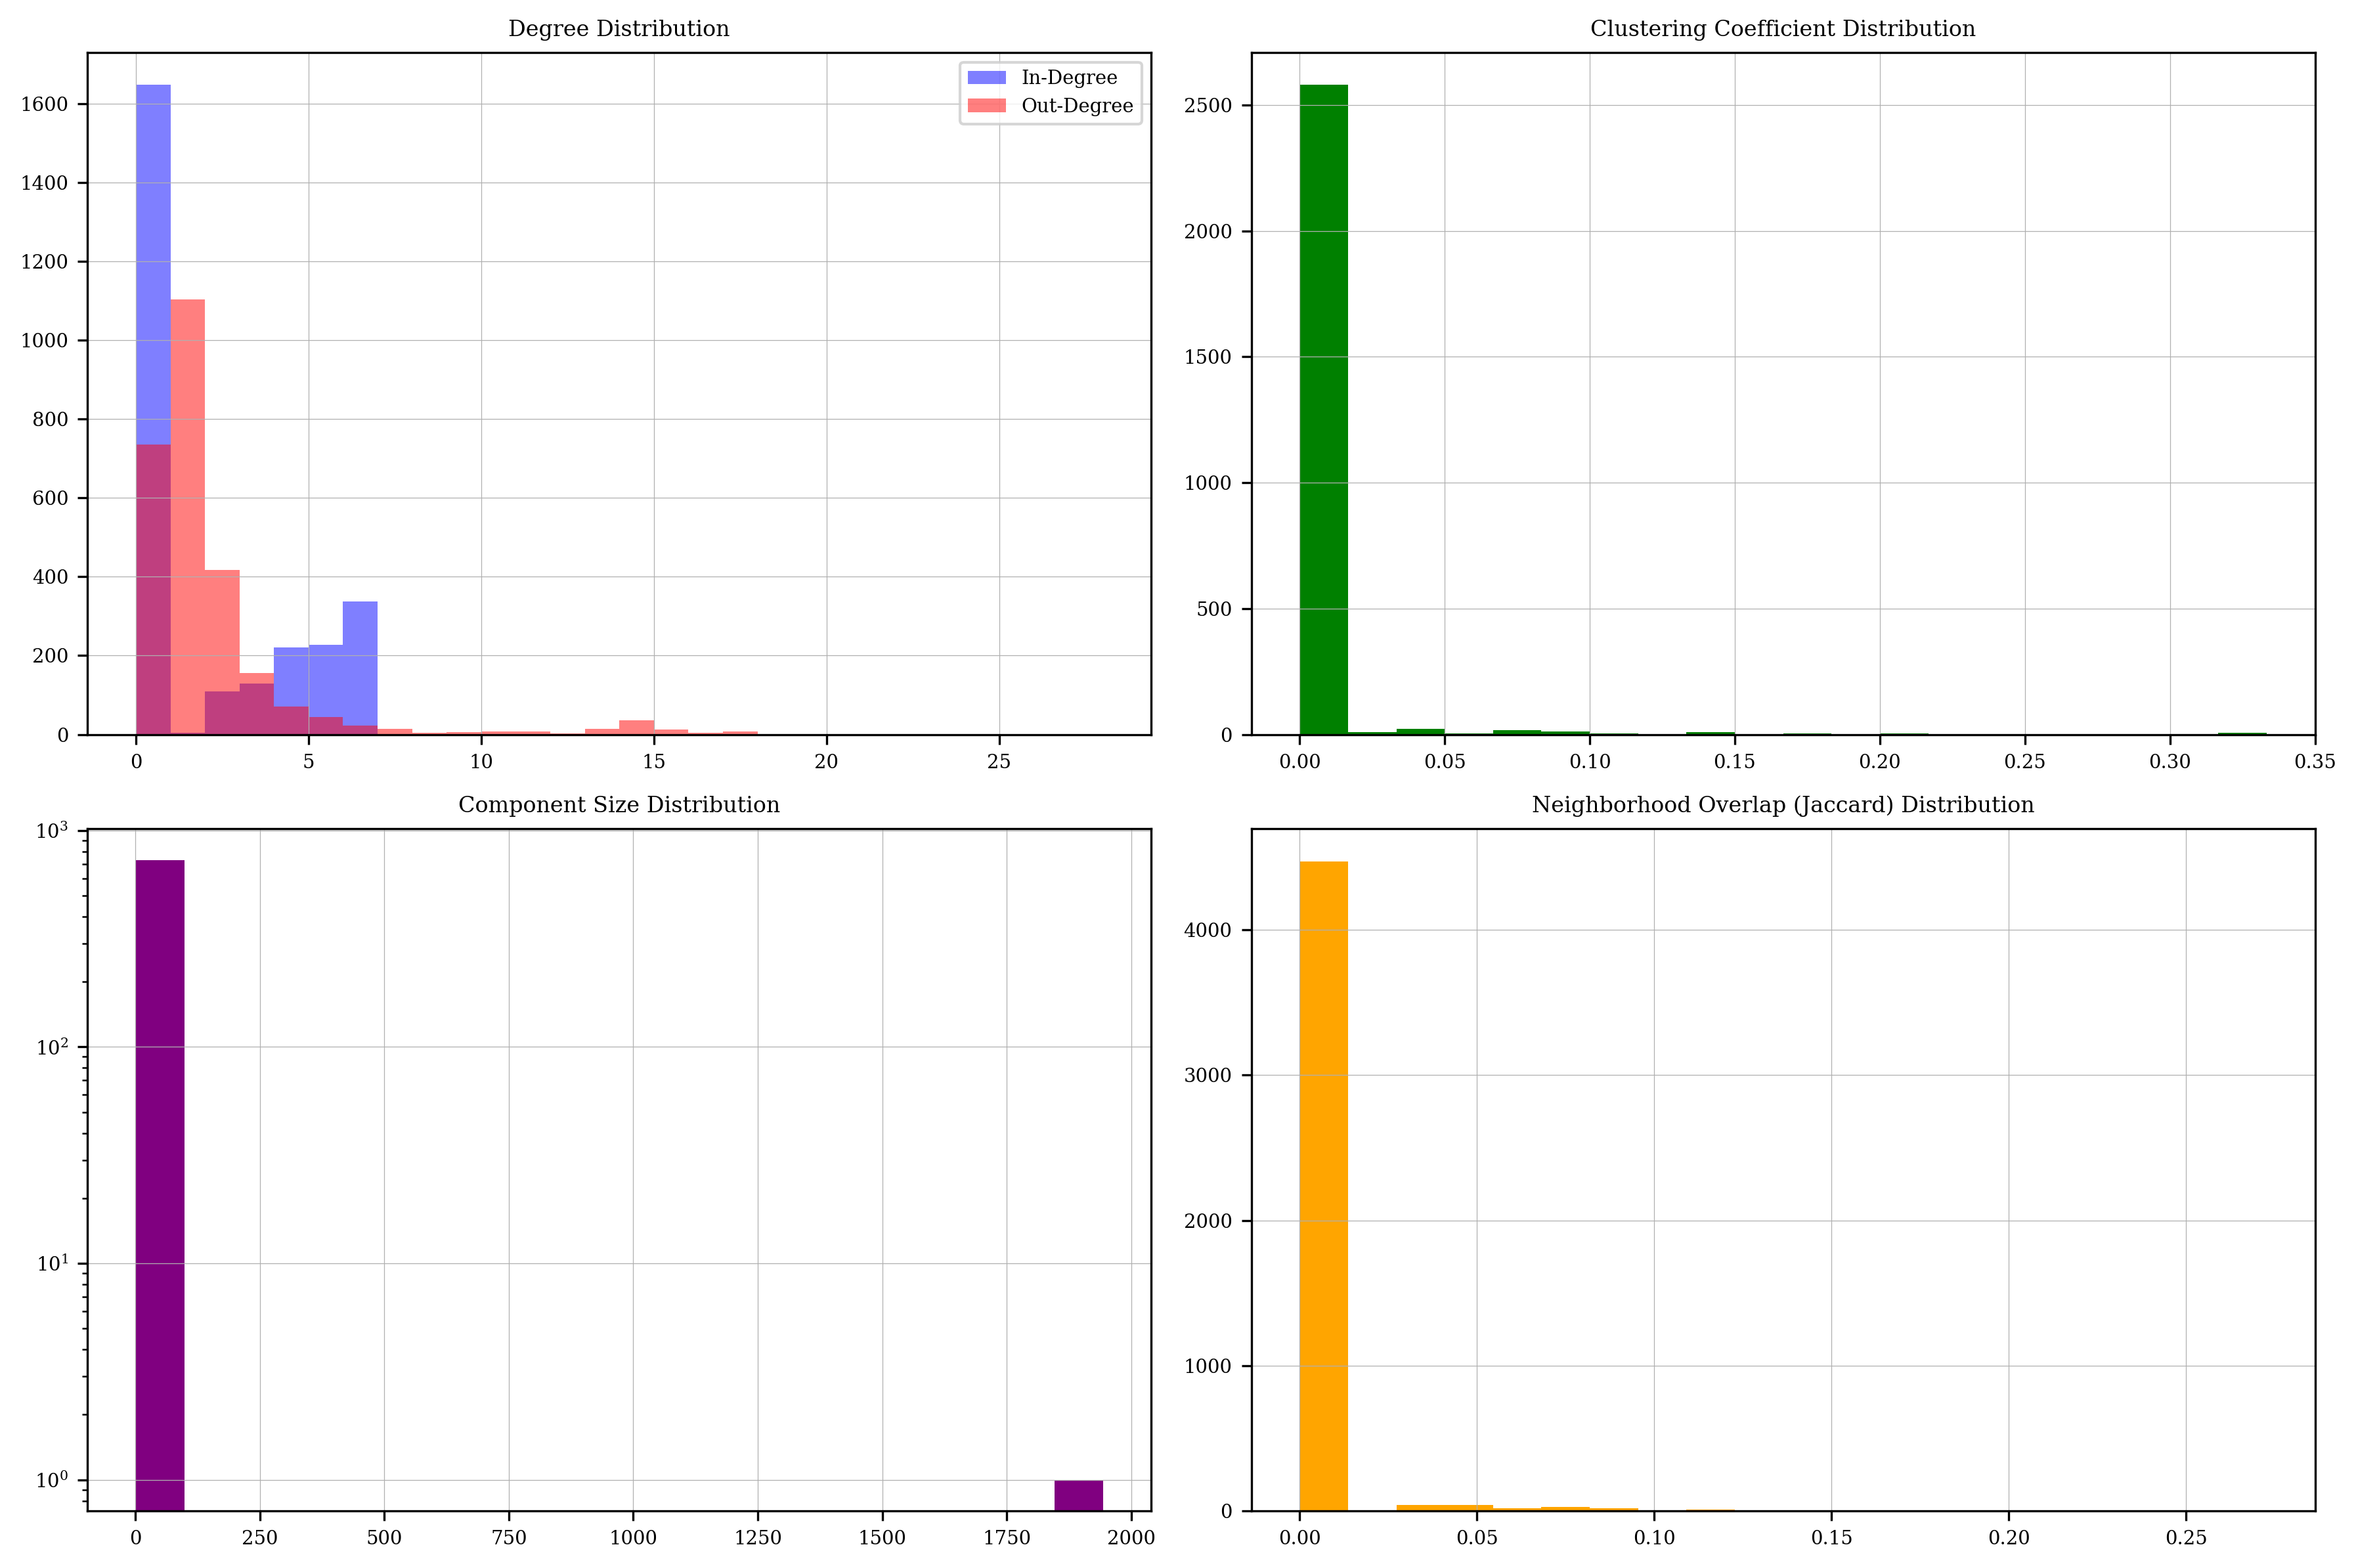

Node type distribution:
  input: 1648
  output: 4
  $lut: 1022

Node degree statistics:
  input: avg in-degree = 0.00, avg out-degree = 0.73
  output: avg in-degree = 1.00, avg out-degree = 0.00
  $lut: avg in-degree = 4.54, avg out-degree = 3.37


FileNotFoundError: [Errno 2] No such file or directory: '../../results/paviaU_/paviaU_/lut_degree_distribution.png'

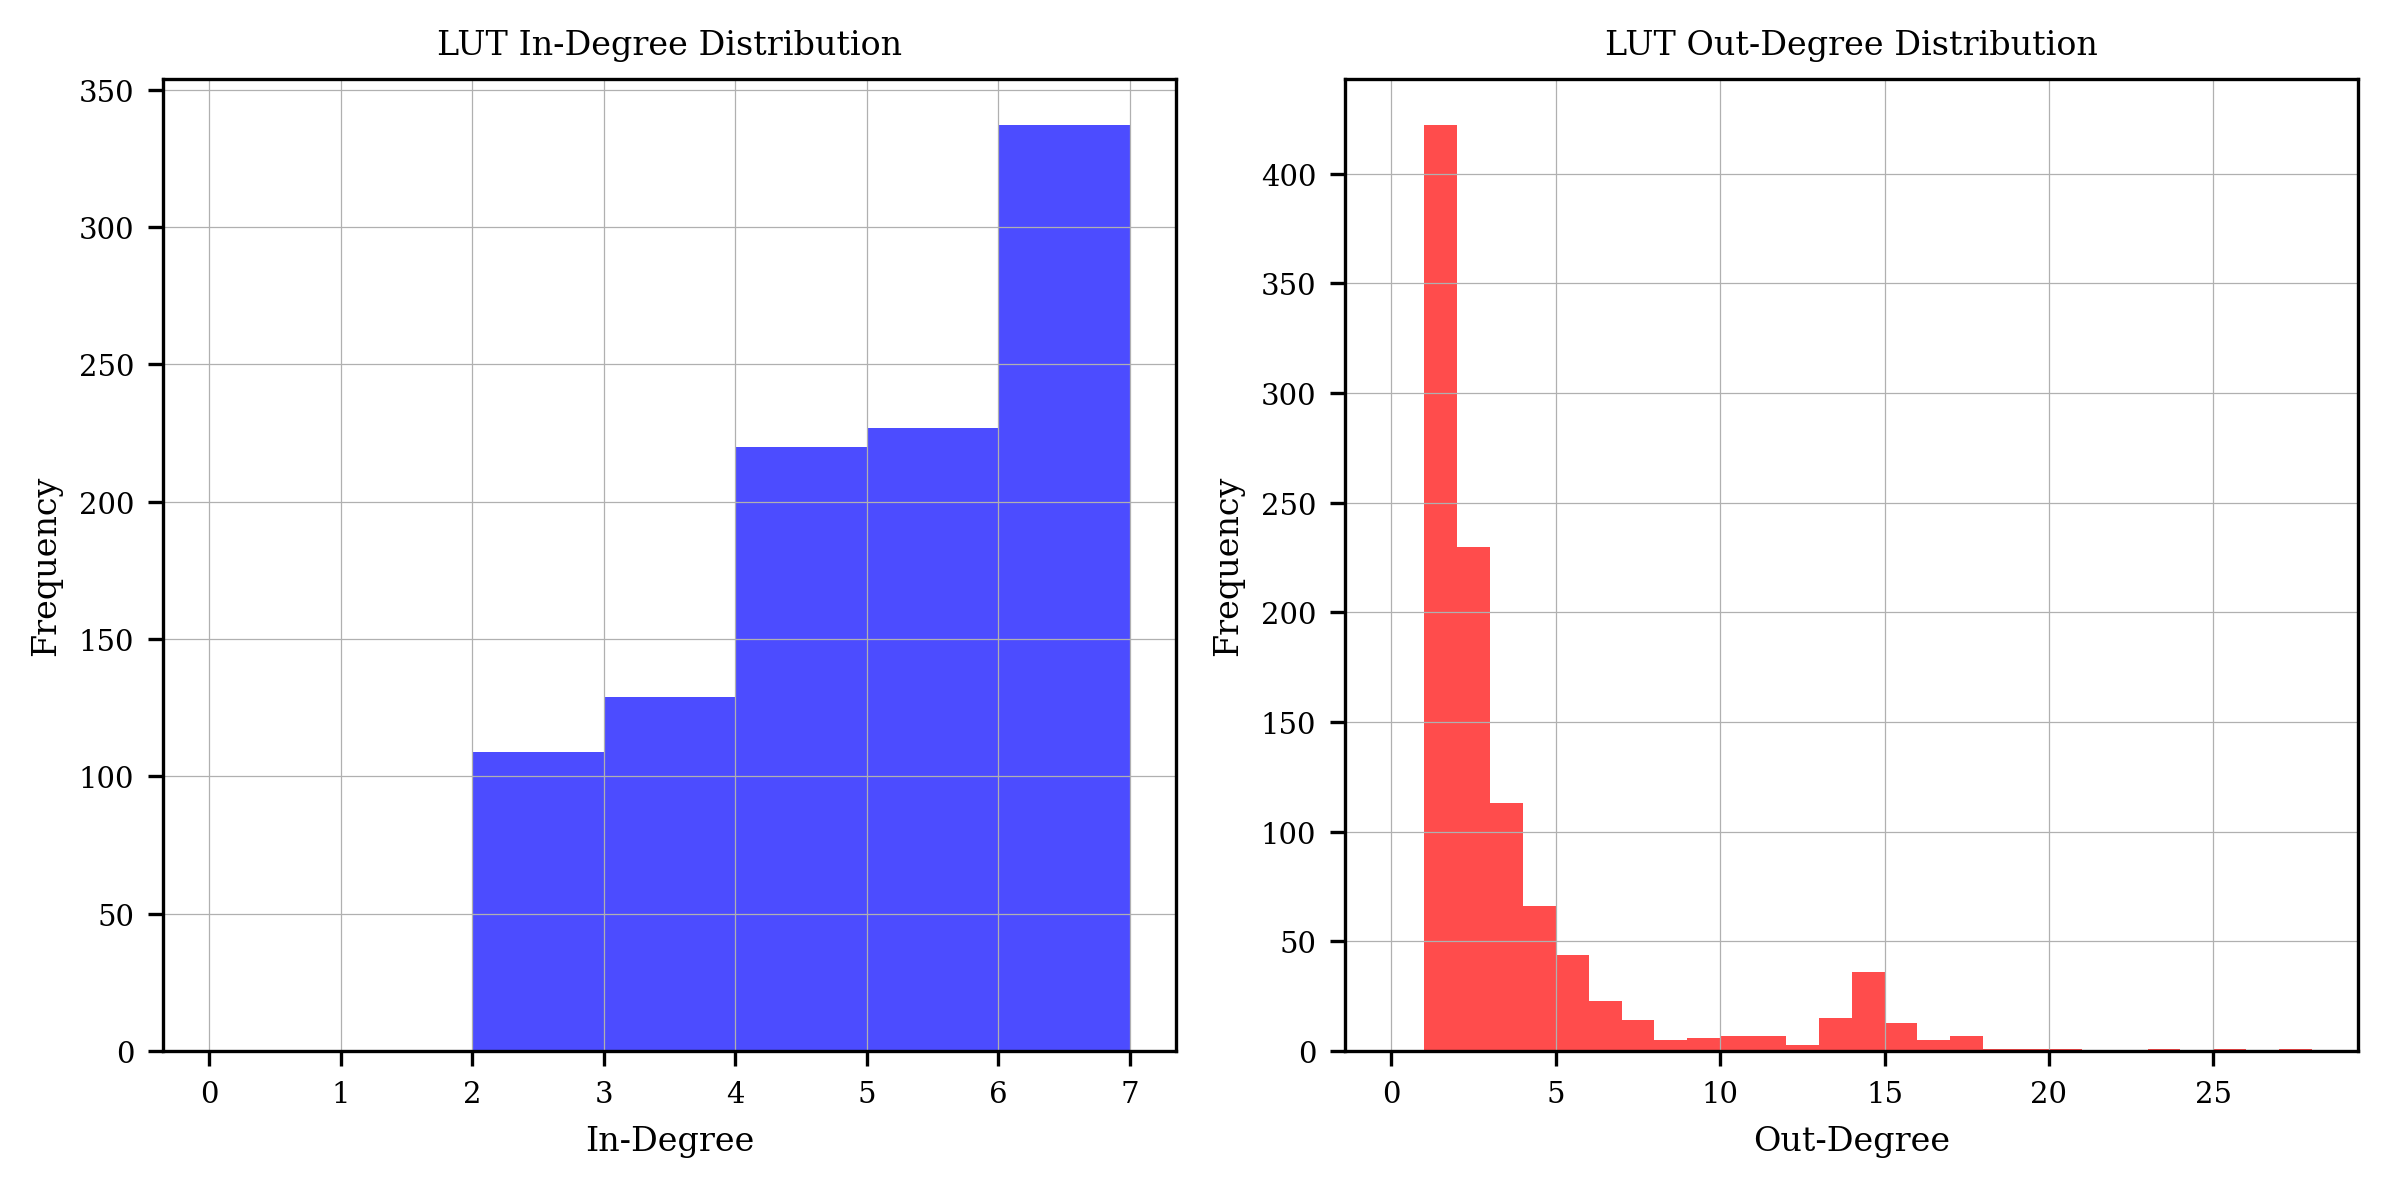

In [ ]:
# Execute the pipeline
G = build_graph_from_yosys(JSON_FILE)

# Export to gephi
nx.write_gexf(G, RESULTS_PATH / "graph.gexf")

print(f"Graph constructed with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

calculate_tp1_metrics(G)

# Get node statistics
node_types = {}
for node, data in G.nodes(data=True):
    node_type = data.get('type', 'unknown')
    node_types[node_type] = node_types.get(node_type, 0) + 1
print("Node type distribution:")
for node_type, count in node_types.items():
    print(f"  {node_type}: {count}")

# Node degrees per type and per input/output degree
degree_stats = {}
for node, data in G.nodes(data=True):
    node_type = data.get('type', 'unknown')
    in_degree = G.in_degree(node)
    out_degree = G.out_degree(node)
    
    if node_type not in degree_stats:
        degree_stats[node_type] = {
            'in_degree': [],
            'out_degree': []
        }
    
    degree_stats[node_type]['in_degree'].append(in_degree)
    degree_stats[node_type]['out_degree'].append(out_degree)
print("\nNode degree statistics:")
for node_type, stats in degree_stats.items():
    avg_in = np.mean(stats['in_degree'])
    avg_out = np.mean(stats['out_degree'])
    print(f"  {node_type}: avg in-degree = {avg_in:.2f}, avg out-degree = {avg_out:.2f}")

# Plot degree distribution for LUT nodes
lut_in_degrees = degree_stats.get('$lut', {}).get('in_degree', [])
lut_out_degrees = degree_stats.get('$lut', {}).get('out_degree', [])
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(lut_in_degrees, bins=range(max(lut_in_degrees)+2
), alpha=0.7, color='blue')
plt.title('LUT In-Degree Distribution')
plt.xlabel('In-Degree')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
plt.hist(lut_out_degrees, bins=range(max(lut_out_degrees)+2), alpha=0.7, color='red')
plt.title('LUT Out-Degree Distribution')
plt.xlabel('Out-Degree')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(RESULTS_PATH  / "lut_degree_distribution.png")
plt.show()

